# Seurat integration of in vitro and in vivo multiome - RNA

In [2]:
here::i_am("multiome_atlas_integration/RNA_seurat.ipynb")

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(uwot))
suppressPackageStartupMessages(library(Seurat))

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘destiny’ was built under R version 4.1.3”
Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


In [3]:
args <- list()
# in vitro
args$sce_query <-file.path(io$basedir,"processed/rna/SingleCellExperiment.rds")
args$metadata_query <- file.path(io$basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')

# in vivo
io$atlas.basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'
args$sce_atlas <-file.path(io$atlas.basedir,"data/processed/rna/SingleCellExperiment.rds")
args$metadataRNA_atlas <- file.path(io$atlas.basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$metadataATAC_atlas <- file.path(io$atlas.basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')
args$celltype_label <- "celltype"

args$sample <- c('E7.5_rep1','E7.5_rep2','E7.75_rep1','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2')

# Trajectory 
opts$celltypes = c("Epiblast",
                    "Primitive_Streak" ,
                    "Anterior_Primitive_Streak",
                    "Nascent_mesoderm",
                    "Intermediate_mesoderm", 
                    "Pharyngeal_mesoderm",
                    "ExE_mesoderm",
                    "Mixed_mesoderm",
                    "Allantois",
                    "Mesenchyme",
                    "Haematoendothelial_progenitors",
                    "Endothelium",
                    "Blood_progenitors_1",
                    "Blood_progenitors_2",
                    "Erythroid1",
                    "Erythroid2",
                    "Erythroid3",
                    "PGC",
                    "Surface_ectoderm")

# I/O
args$outdir = file.path(io$basedir, 'results/multiome_atlas_integration/rna')
dir.create(args$outdir, showWarnings=F, recursive=T)

In [4]:
#########################
## Load in vitro RNA  ##
#########################
metadata_query <- fread(args$metadata_query) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE & pass_atacQC==TRUE]

##############
## Load RNA ##
##############

sce <- load_SingleCellExperiment(
  file = args$sce_query, 
  normalise = TRUE, 
  cells = metadata_query$cell, 
  remove_non_expressed_genes = TRUE
)

colData(sce) <- metadata_query %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

sce_query = sce

In [7]:
######################
## Load in vivo RNA ##
######################

metadata_atlas <- fread(args$metadataRNA_atlas) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>%
    merge(.,fread(args$metadataATAC_atlas)[,c('cell', 'pass_atacQC')], by='cell') %>%
    .[pass_atacQC==TRUE]

stopifnot(args$celltype_label%in%colnames(metadata_atlas))
metadata_atlas <- metadata_atlas   %>%
  .[,celltype:=eval(as.name(args$celltype_label))] %>%
  .[celltype%in%opts$celltypes] %>%
  .[,celltype:=factor(celltype,levels=opts$celltypes)] %>%
  .[sample%in% args$sample]

table(metadata_atlas$celltype)

##############
## Load RNA ##
##############
  

sce <- load_SingleCellExperiment(
  file = args$sce_atlas, 
  normalise = TRUE, 
  cells = metadata_atlas$cell, 
  remove_non_expressed_genes = TRUE
)

colData(sce) <- metadata_atlas %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

sce_atlas = sce


                      Epiblast               Primitive_Streak 
                           984                            542 
     Anterior_Primitive_Streak               Nascent_mesoderm 
                           138                           1327 
         Intermediate_mesoderm            Pharyngeal_mesoderm 
                           808                           1710 
                  ExE_mesoderm                 Mixed_mesoderm 
                          1173                            265 
                     Allantois                     Mesenchyme 
                           653                           3123 
Haematoendothelial_progenitors                    Endothelium 
                           913                            666 
           Blood_progenitors_1            Blood_progenitors_2 
                           230                            565 
                    Erythroid1                     Erythroid2 
                          1119                        

In [8]:
colData(sce_query) <- colData(sce_query) %>% 
    as.data.table(keep.rownames=T) %>% 
    .[,c('rn', 'sample', 'day', 'celltype', 'genotype')] %>% 
    setnames(c('cell', 'sample', 'stage', 'celltype', 'genotype')) %>%
    as.data.frame %>% tibble::column_to_rownames("cell") %>% 
    DataFrame()

colData(sce_atlas) <- colData(sce_atlas) %>% 
    as.data.table(keep.rownames=T) %>% 
    .[,c('rn', 'sample', 'stage', 'celltype', 'genotype')] %>% 
    setnames(c('cell', 'sample', 'stage', 'celltype', 'genotype')) %>%
    as.data.frame %>% tibble::column_to_rownames("cell") %>% 
    DataFrame()

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”
Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [9]:
seurat_query = as.Seurat(sce_query)
seurat_atlas = as.Seurat(sce_atlas)

In [ ]:
#################
## Seurat rPCA ##
#################

In [12]:
seurat.list = list(seurat_query, seurat_atlas)
names(seurat.list) = c('query', 'atlas')

In [13]:
# split the dataset into a list of two seurat objects (stim and CTRL)
#seurat.list <- SplitObject(seurat, split.by = "sample")

# normalize and identify variable features for each dataset independently
seurat.list <- lapply(X = seurat.list, FUN = function(x) {
    x <- NormalizeData(x)
    x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = 2000)
})

# select features that are repeatedly variable across datasets for integration run PCA on each
# dataset using these features
features <- SelectIntegrationFeatures(object.list = seurat.list)
seurat.list <- lapply(X = seurat.list, FUN = function(x) {
    x <- ScaleData(x, features = features, verbose = FALSE)
    x <- RunPCA(x, features = features, verbose = FALSE)
})

In [14]:
seurat.anchors <- FindIntegrationAnchors(object.list = seurat.list, anchor.features = features, reduction = "rpca")
# this command creates an 'integrated' data assay
seurat.combined <- IntegrateData(anchorset = seurat.anchors)

Scaling features for provided objects

Computing within dataset neighborhoods

Finding all pairwise anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 3277 anchors

Merging dataset 2 into 1

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data



In [15]:
# specify that we will perform downstream analysis on the corrected data note that the
# original unmodified data still resides in the 'RNA' assay
DefaultAssay(seurat.combined) <- "integrated"

# Run the standard workflow for visualization and clustering
seurat.combined <- ScaleData(seurat.combined, verbose = FALSE)
seurat.combined <- RunPCA(seurat.combined, npcs = 30, verbose = FALSE)
seurat.combined <- RunUMAP(seurat.combined, reduction = "pca", dims = 1:30)
seurat.combined <- FindNeighbors(seurat.combined, reduction = "pca", dims = 1:30)
seurat.combined <- FindClusters(seurat.combined, resolution = 0.5)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
13:08:02 UMAP embedding parameters a = 0.9922 b = 1.112

13:08:02 Read 51163 rows and found 30 numeric columns

13:08:02 Using Annoy for neighbor search, n_neighbors = 30

13:08:02 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:08:07 Writing NN index file to temp file /tmp/Rtmp0b1arB/file1130250eb8935

13:08:07 Searching Annoy index using 1 thread, search_k = 3000

13:08:23 Annoy recall = 100%

13:08:24 Commencing smooth kNN distance calibration using 1 thread

13:08:27 Initializing f

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 51163
Number of edges: 1826705

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9165
Number of communities: 15
Elapsed time: 12 seconds


In [20]:
head(seurat.combined@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,sample,stage,celltype,genotype,integrated_snn_res.0.5,seurat_clusters
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,1A,22917,6104,1A_Eo_DEG_G9_day3,D3,Epiblast,wt,2,2
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,1A,10793,4200,1A_Eo_DEG_G9_day3,D3,Primitive_Streak,wt,2,2
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,1A,8745,3659,1A_Eo_DEG_G9_day3,D3,Epiblast,wt,2,2
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,1A,8460,3639,1A_Eo_DEG_G9_day3,D3,Primitive_Streak,wt,2,2
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,1A,8276,3632,1A_Eo_DEG_G9_day3,D3,Epiblast,wt,2,2
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,1A,15675,4877,1A_Eo_DEG_G9_day3,D3,Primitive_Streak,wt,2,2


In [18]:
# Visualization
options(repr.plot.width=25, repr.plot.height=8)
p1 <- DimPlot(seurat.combined, reduction = "umap", group.by = "celltype") +
        scale_colour_manual(values=opts$celltype.colors)
p2 <- DimPlot(seurat.combined, reduction = "umap", group.by = "sample", label = TRUE,
    repel = TRUE)

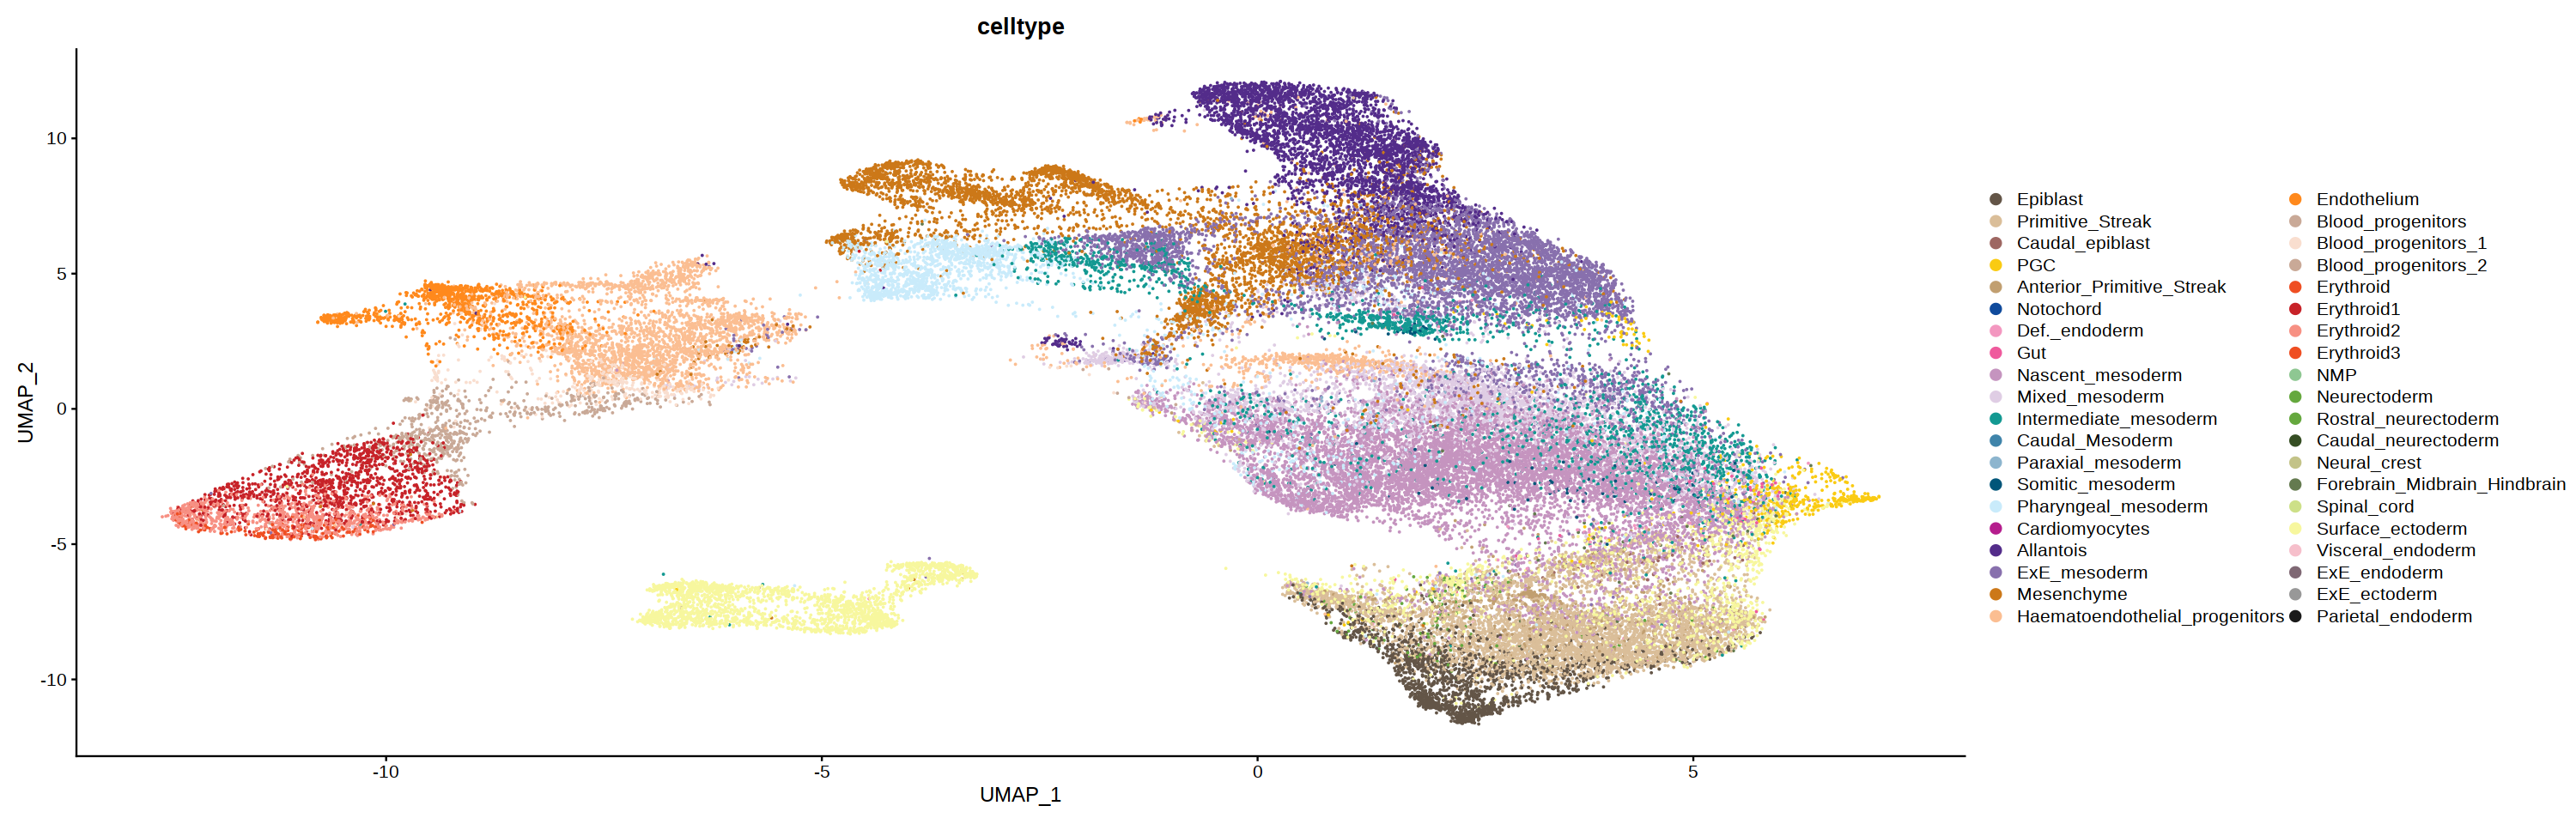

In [21]:
p1

In [26]:
unique(seurat.combined@meta.data$stage)

[1] "D3"    "D3.5"  "D4"    "D5"    "D4.5"  "E7.5"  "E7.75" "E8.0"  "E8.5" 
[10] "E8.75"

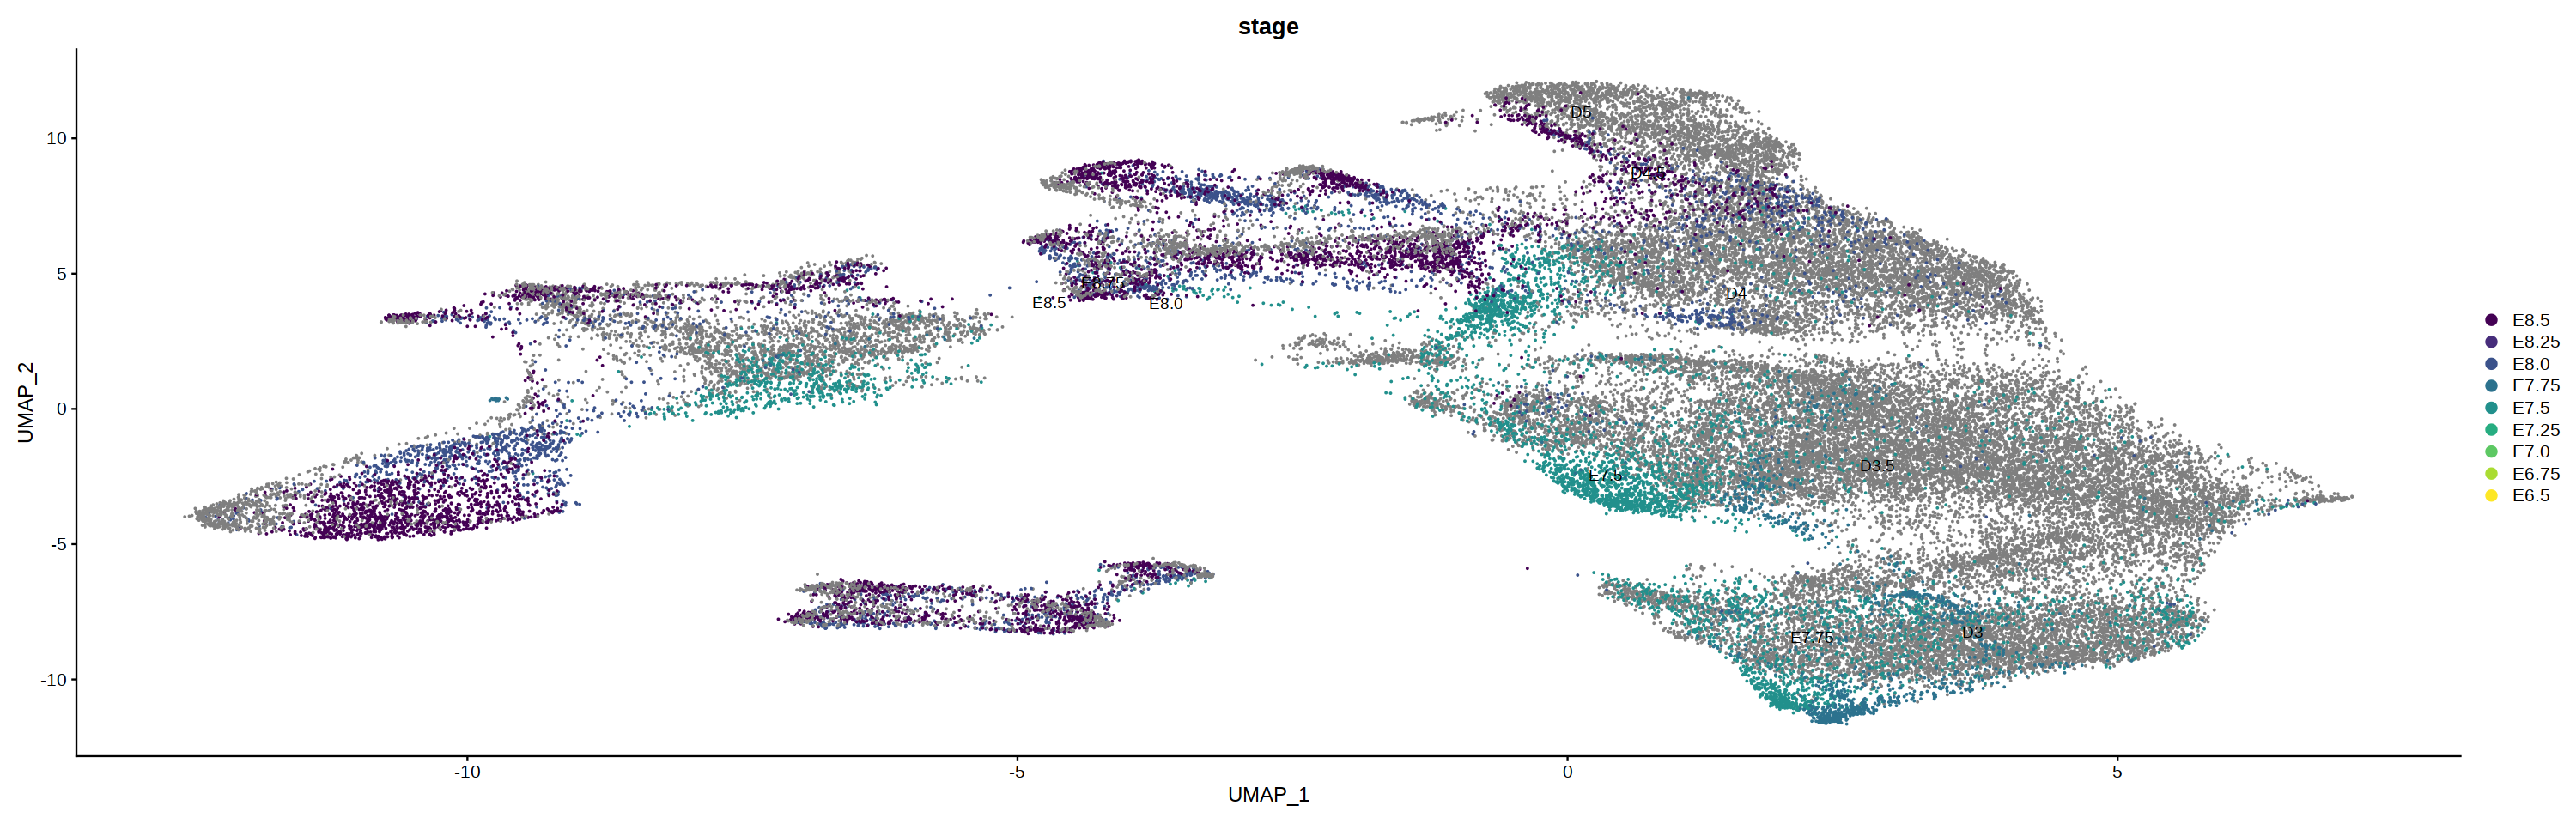

In [23]:
DimPlot(seurat.combined, reduction = "umap", group.by = "stage", label = TRUE,
    repel = TRUE) +         scale_colour_manual(values=opts$stage.colors)


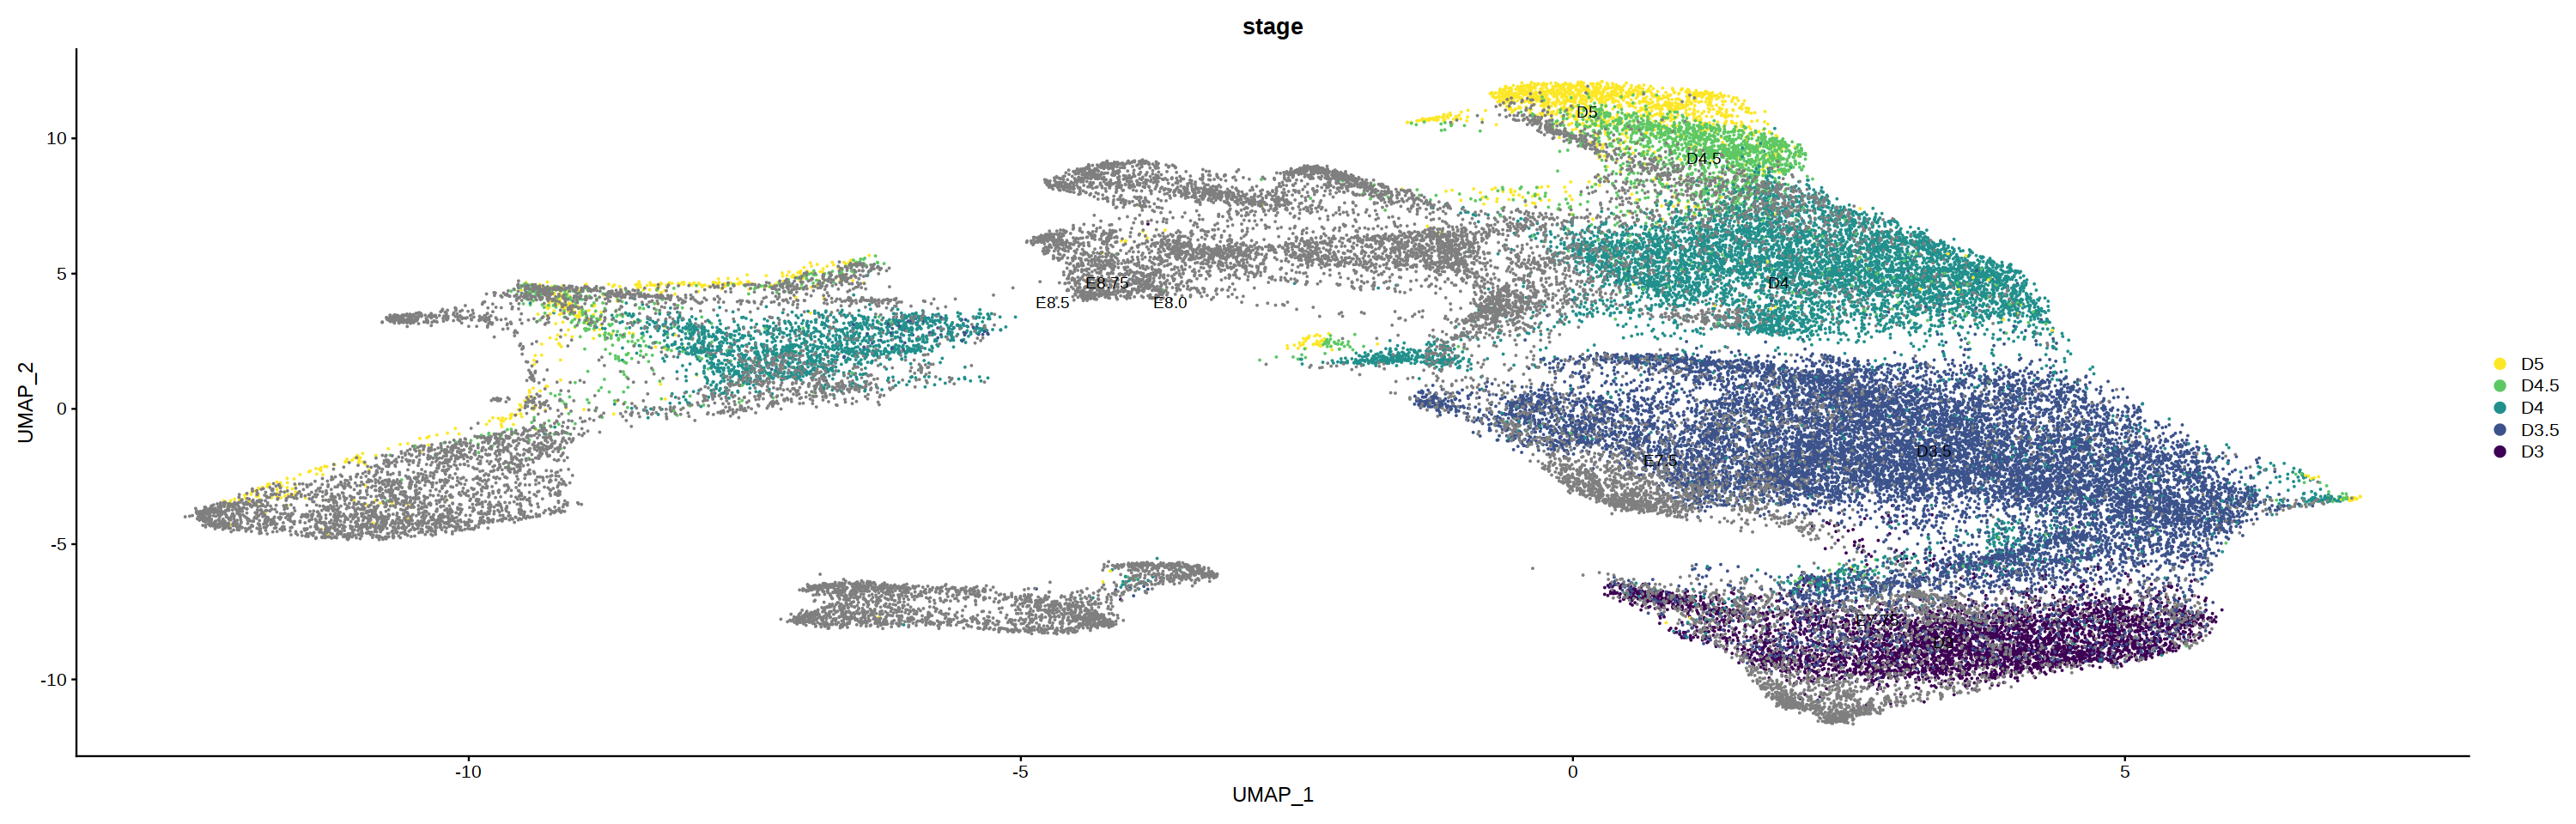

In [25]:
DimPlot(seurat.combined, reduction = "umap", group.by = "stage", label = TRUE,
    repel = TRUE) +         scale_colour_manual(values=opts$days.colors)


# Trial with original atlas

In [1]:
here::i_am("multiome_atlas_integration/RNA_seurat.ipynb")

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(uwot))
suppressPackageStartupMessages(library(Seurat))

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘destiny’ was built under R version 4.1.3”
Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


In [2]:
args <- list()
# in vitro
args$sce_query <-file.path(io$basedir,"processed/rna/SingleCellExperiment.rds")
args$metadata_query <- file.path(io$basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')

# in vivo
io$atlas.basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/'
args$sce_atlas <-file.path(io$atlas.basedir,"processed/SingleCellExperiment.rds")
args$metadataRNA_atlas <- file.path(io$atlas.basedir, 'sample_metadata.txt.gz')

# Trajectory 
opts$celltypes = c("Epiblast",
                    "Primitive_Streak" ,
                    "Anterior_Primitive_Streak",
                    "Nascent_mesoderm",
                    "Intermediate_mesoderm", 
                    "Pharyngeal_mesoderm",
                    "ExE_mesoderm",
                    "Mixed_mesoderm",
                    "Allantois",
                    "Mesenchyme",
                    "Haematoendothelial_progenitors",
                    "Endothelium",
                    "Blood_progenitors_1",
                    "Blood_progenitors_2",
                    "Erythroid1",
                    "Erythroid2",
                    "Erythroid3",
                    "PGC",
                    "Surface_ectoderm")

# I/O
args$outdir = file.path(io$basedir, 'results/atlas_integration/rna')
dir.create(args$outdir, showWarnings=F, recursive=T)

In [31]:
#########################
## Load in vitro RNA  ##
#########################
metadata_query <- fread(args$metadata_query) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE & pass_atacQC==TRUE]

##############
## Load RNA ##
##############

sce <- load_SingleCellExperiment(
  file = args$sce_query, 
  normalise = T, 
  cells = metadata_query$cell, 
  remove_non_expressed_genes = TRUE
)

colData(sce) <- metadata_query %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

sce_query = sce

In [41]:
######################
## Load in vivo RNA ##
######################

metadata_atlas <- fread(args$metadataRNA_atlas) %>%
  .[celltype %in% opts$celltypes] %>%
    .[,genotype:='wt-atlas']

table(metadata_atlas$celltype)

##############
## Load RNA ##
##############
  

sce <- load_SingleCellExperiment(
  file = args$sce_atlas, 
  normalise = T, 
  cells = metadata_atlas$cell, 
  remove_non_expressed_genes = TRUE
)

colData(sce) <- metadata_atlas %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

sce_atlas = sce


                     Allantois      Anterior_Primitive_Streak 
                          1820                           1158 
           Blood_progenitors_1            Blood_progenitors_2 
                           745                           2587 
                   Endothelium                       Epiblast 
                          1084                          14619 
                    Erythroid1                     Erythroid2 
                          2929                           1106 
                    Erythroid3                   ExE_mesoderm 
                          2697                           2571 
Haematoendothelial_progenitors          Intermediate_mesoderm 
                          2733                           3551 
                    Mesenchyme                 Mixed_mesoderm 
                          4979                           1994 
              Nascent_mesoderm                            PGC 
                          5028                        

In [33]:
colData(sce_query) <- colData(sce_query) %>% 
    as.data.table(keep.rownames=T) %>% 
    .[,c('rn', 'sample', 'day', 'celltype', 'genotype')] %>% 
    setnames(c('cell', 'sample', 'stage', 'celltype', 'genotype')) %>%
    as.data.frame %>% tibble::column_to_rownames("cell") %>% 
    DataFrame()

colData(sce_atlas) <- colData(sce_atlas) %>% 
    as.data.table(keep.rownames=T) %>% 
    .[,c('rn', 'sample', 'stage', 'celltype', 'genotype')] %>% 
    setnames(c('cell', 'sample', 'stage', 'celltype', 'genotype')) %>%
    as.data.frame %>% tibble::column_to_rownames("cell") %>% 
    DataFrame()

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”
Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [34]:
# # Rename gene_ids from atlas to symbol
# biomart = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.87.txt')
# sce_atlas = sce_atlas[rownames(sce_atlas)[rownames(sce_atlas) %in% biomart$ens_id],]
# rownames(sce_atlas) = biomart[match(rownames(sce_atlas), ens_id), symbol]

In [40]:
head(counts(sce_atlas))

   [[ suppressing 34 column names ‘cell_1’, ‘cell_10’, ‘cell_100’ ... ]]



6 x 63867 sparse Matrix of class "dgCMatrix"
                                                                              
Xkr4    . .  . . . . . . . . . . . . . . . .  . .  . .  .  . . . . . . . . . .
Sox17   . .  . . . . . . . . . . . . . . . .  . .  . .  .  . . 1 . . 6 . . . .
Mrpl15  3 3 11 7 6 4 3 3 4 1 7 6 4 3 3 1 8 9 11 5 14 3 10 10 . . 2 3 3 6 1 1 2
Lypla1  2 .  5 1 . 1 1 2 . 1 . 1 . . . . . 1  . 1  4 .  .  . 1 1 . 1 . 2 . 1 1
Gm37988 . .  . . . . . . . . . . . . . . . .  . .  . .  .  . . . . . . . . . .
Tcea1   1 2  3 2 . . 1 1 1 1 1 . 1 1 1 1 . 1  1 3  . .  1  1 1 . 3 1 . 2 2 . 1
                
Xkr4    . ......
Sox17   . ......
Mrpl15  7 ......
Lypla1  1 ......
Gm37988 . ......
Tcea1   1 ......

 .....suppressing 63833 columns in show(); maybe adjust 'options(max.print= *, width = *)'
 ..............................

In [43]:
seurat_query = as.Seurat(sce_query)
seurat_atlas = as.Seurat(sce_atlas)

In [47]:
seurat_atlas@assays$counts = seurat_atlas@assays$originalexp

In [45]:
seurat_query

An object of class Seurat 
22812 features across 33177 samples within 1 assay 
Active assay: RNA (22812 features, 0 variable features)

In [ ]:
#################
## Seurat rPCA ##
#################

seurat.list = list(seurat_query, seurat_atlas)
names(seurat.list) = c('query', 'atlas')

# split the dataset into a list of two seurat objects (stim and CTRL)
#seurat.list <- SplitObject(seurat, split.by = "sample")

# normalize and identify variable features for each dataset independently
seurat.list <- lapply(X = seurat.list, FUN = function(x) {
    x <- NormalizeData(x)
    x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = 2000)
})

# select features that are repeatedly variable across datasets for integration run PCA on each
# dataset using these features
features <- SelectIntegrationFeatures(object.list = seurat.list)
seurat.list <- lapply(X = seurat.list, FUN = function(x) {
    x <- ScaleData(x, features = features, verbose = FALSE)
    x <- RunPCA(x, features = features, verbose = FALSE)
})

seurat.anchors <- FindIntegrationAnchors(object.list = seurat.list, anchor.features = features, reduction = "rpca")
# this command creates an 'integrated' data assay
seurat.combined <- IntegrateData(anchorset = seurat.anchors)

In [ ]:
# specify that we will perform downstream analysis on the corrected data note that the
# original unmodified data still resides in the 'RNA' assay
DefaultAssay(seurat.combined) <- "integrated"

# Run the standard workflow for visualization and clustering
seurat.combined <- ScaleData(seurat.combined, verbose = FALSE)
seurat.combined <- RunPCA(seurat.combined, npcs = 30, verbose = FALSE)
seurat.combined <- RunUMAP(seurat.combined, reduction = "pca", dims = 1:30)
seurat.combined <- FindNeighbors(seurat.combined, reduction = "pca", dims = 1:30)
seurat.combined <- FindClusters(seurat.combined, resolution = 0.5)

In [ ]:
# Visualization
options(repr.plot.width=25, repr.plot.height=8)
p1 <- DimPlot(seurat.combined, reduction = "umap", group.by = "celltype") +
        scale_colour_manual(values=opts$celltype.colors)
p2 <- DimPlot(seurat.combined, reduction = "umap", group.by = "sample", label = TRUE,
    repel = TRUE)

In [ ]:
p1

In [26]:
unique(seurat.combined@meta.data$stage)

[1] "D3"    "D3.5"  "D4"    "D5"    "D4.5"  "E7.5"  "E7.75" "E8.0"  "E8.5" 
[10] "E8.75"

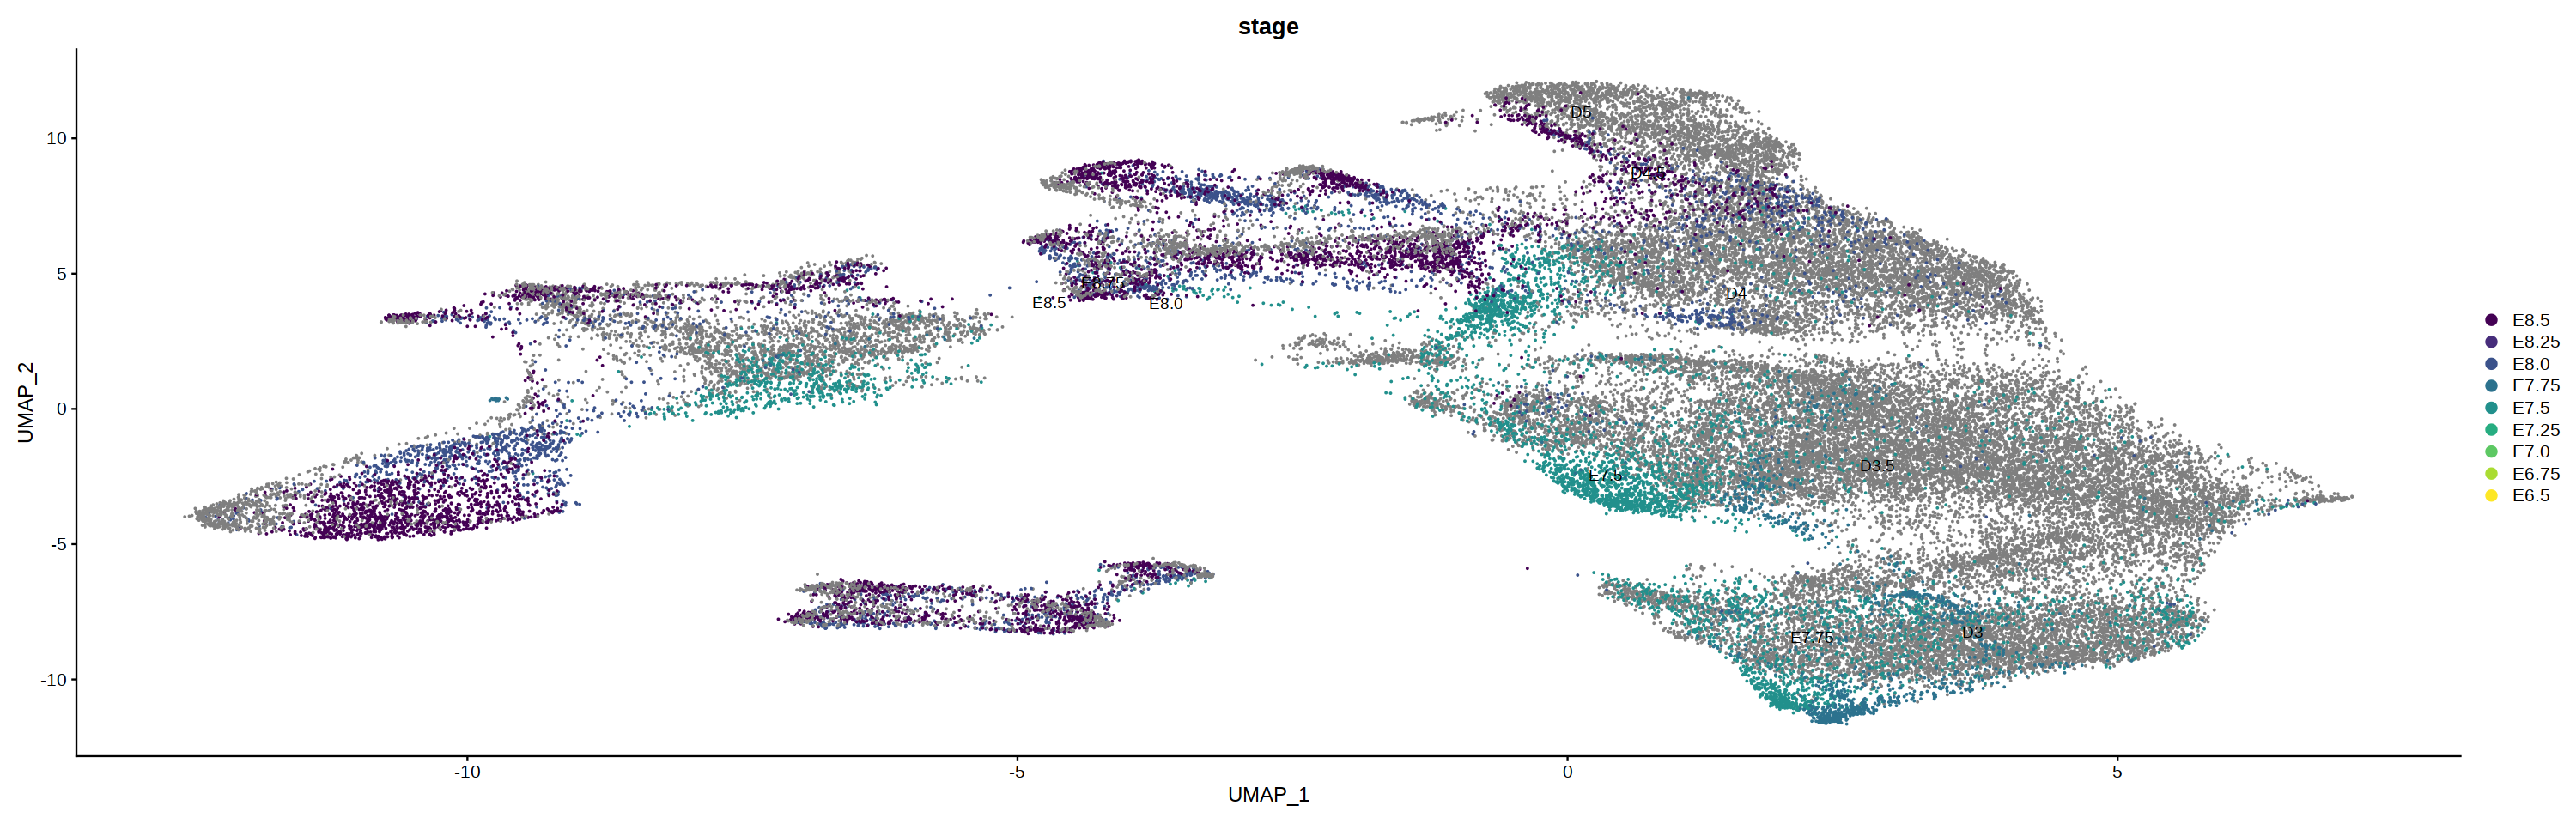

In [23]:
DimPlot(seurat.combined, reduction = "umap", group.by = "stage", label = TRUE,
    repel = TRUE) +         scale_colour_manual(values=opts$stage.colors)


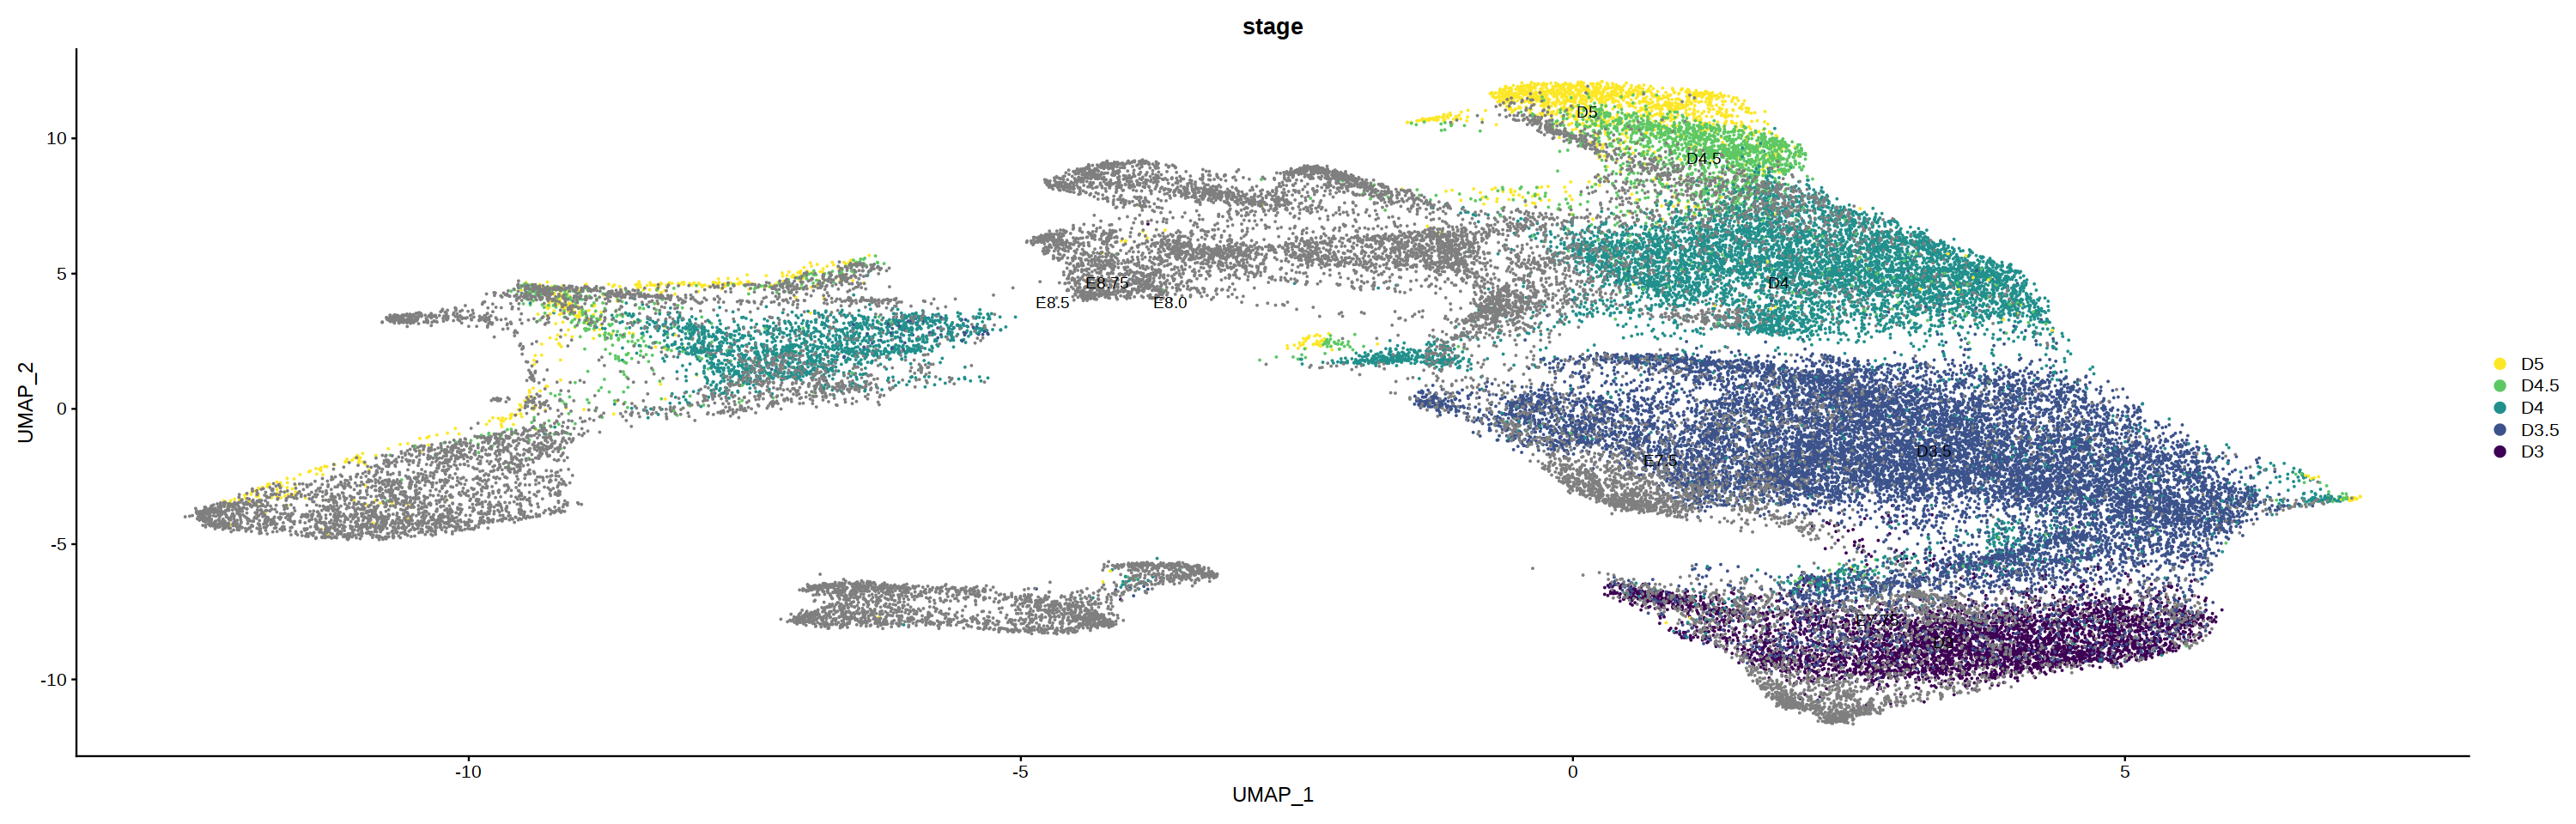

In [25]:
DimPlot(seurat.combined, reduction = "umap", group.by = "stage", label = TRUE,
    repel = TRUE) +         scale_colour_manual(values=opts$days.colors)
